### Product Recommendation System

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error
sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'DejaVu Serif'
print("Libraries ready.")

Libraries ready.


### Load the dataset

In [2]:
items = pd.read_csv('medicine_items.csv')
ratings = pd.read_csv('medicine_ratings.csv', parse_dates=['timestamp'])
print("Items:", items.shape, " Ratings:", ratings.shape)
items.head()

Items: (60, 6)  Ratings: (1500, 4)


,item_id,title,category,tags,price,description
0,1,Essential Pain Relief Item 1,Pain Relief,topical tablet migraine analgesic backache,24.94,Essential Pain Relief Item 1. Tags: topical ta...
1,2,Gentle Pain Relief Item 2,Pain Relief,migraine muscle analgesic tablet fever,10.05,Gentle Pain Relief Item 2. Tags: migraine musc...
2,3,Premium Pain Relief Item 3,Pain Relief,backache topical tablet muscle fever,32.12,Premium Pain Relief Item 3. Tags: backache top...
3,4,Essential Pain Relief Item 4,Pain Relief,joint muscle headache topical migraine,26.48,Essential Pain Relief Item 4. Tags: joint musc...
4,5,Extra-Strength Pain Relief Item 5,Pain Relief,tablet backache headache muscle fever,12.97,Extra-Strength Pain Relief Item 5. Tags: table...


In [3]:
ratings.head()

,user_id,item_id,rating,timestamp
0,1,53,4,2025-08-22
1,1,58,4,2025-05-19
2,1,60,5,2025-02-09
3,1,54,3,2025-08-09
4,1,55,4,2025-02-15


Users: 130  Items rated: 60
Average ratings per user: 11.5


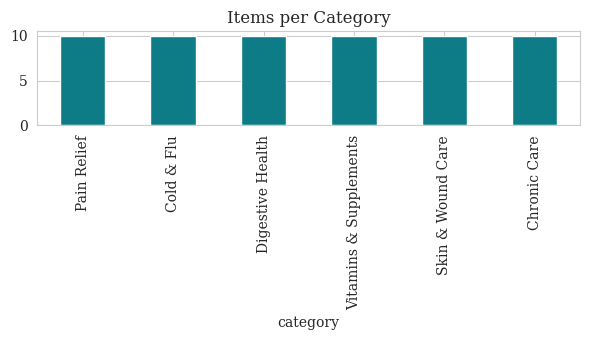

In [4]:
print("Users:", ratings['user_id'].nunique(), " Items rated:", ratings['item_id'].nunique())
print("Average ratings per user:", round(ratings.groupby('user_id').size().mean(), 1))
items['category'].value_counts().plot.bar(figsize=(6,3.5), color='#0E7C86', title='Items per Category')
plt.tight_layout(); plt.show()

### Content-based filtering

In [5]:
tfidf = TfidfVectorizer(stop_words='english')
item_vectors = tfidf.fit_transform(items['description'])
print("TF-IDF matrix shape:", item_vectors.shape)
item_sim = cosine_similarity(item_vectors)
item_sim_df = pd.DataFrame(item_sim, index=items['item_id'], columns=items['item_id'])
item_sim_df.iloc[:5, :5]

TF-IDF matrix shape: (60, 88)


item_id,1,2,3,4,5
item_id,,,,,
1,1.000000,0.622150,0.782039,0.513627,0.649216
2,0.622150,1.000000,0.551064,0.629375,0.599499
3,0.782039,0.551064,1.000000,0.526158,0.752525
4,0.513627,0.629375,0.526158,1.000000,0.460426
5,0.649216,0.599499,0.752525,0.460426,1.000000


In [6]:
def content_based_recommend(item_id, top_n=5):
    scores = item_sim_df.loc[item_id].drop(item_id).sort_values(ascending=False)
    top_ids = scores.head(top_n).index
    result = items[items['item_id'].isin(top_ids)][['item_id','title','category']].copy()
    result['similarity'] = scores.loc[top_ids].values
    return result.sort_values('similarity', ascending=False)
seed_item = items.iloc[0]
print("Because you viewed:", seed_item['title'], f"({seed_item['category']})\n")
content_based_recommend(seed_item['item_id'], top_n=5)

Because you viewed: Essential Pain Relief Item 1 (Pain Relief)



,item_id,title,category,similarity
1,2,Gentle Pain Relief Item 2,Pain Relief,0.788407
2,3,Premium Pain Relief Item 3,Pain Relief,0.782039
4,5,Extra-Strength Pain Relief Item 5,Pain Relief,0.649216
5,6,Fast-Acting Pain Relief Item 6,Pain Relief,0.629288
8,9,Everyday Pain Relief Item 9,Pain Relief,0.622150


### Collaborative filtering (user-based)

In [7]:
user_item = ratings.pivot_table(index='user_id', columns='item_id', values='rating')
print("User-item matrix shape:", user_item.shape)
user_item.iloc[:5, :8]

User-item matrix shape: (130, 60)


item_id,1,2,3,4,5,6,7,8
user_id,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN
3,5.0,5.0,4.0,3.0,5.0,5.0,5.0,4.0
4,NaN,NaN,NaN,NaN,NaN,2.0,NaN,3.0
5,NaN,NaN,NaN,NaN,NaN,NaN,2.0,3.0


In [8]:
filled = user_item.fillna(0)
user_sim = cosine_similarity(filled)
user_sim_df = pd.DataFrame(user_sim, index=user_item.index, columns=user_item.index)
def collaborative_recommend(user_id, top_n=5, k_neighbors=15):
    sims = user_sim_df.loc[user_id].drop(user_id).sort_values(ascending=False).head(k_neighbors)
    neighbor_ratings = user_item.loc[sims.index]
    # weighted average of neighbors' ratings, weighted by similarity
    weighted = neighbor_ratings.mul(sims, axis=0).sum() / sims.abs().sum()
    already_rated = user_item.loc[user_id].dropna().index
    weighted = weighted.drop(already_rated, errors='ignore').dropna().sort_values(ascending=False)
    top_ids = weighted.head(top_n).index
    result = items[items['item_id'].isin(top_ids)][['item_id','title','category']].copy()
    result['predicted_rating'] = weighted.loc[top_ids].values
    return result.sort_values('predicted_rating', ascending=False)
target_user = 1
print("Recommendations for user", target_user, "\n")
collaborative_recommend(target_user, top_n=5)

Recommendations for user 1 



,item_id,title,category,predicted_rating
12,13,Gentle Cold Item 3,Cold & Flu,3.098611
19,20,Gentle Cold Item 10,Cold & Flu,3.052685
50,51,Extra-Strength Chronic Item 1,Chronic Care,3.042509
56,57,Everyday Chronic Item 7,Chronic Care,0.558322
58,59,Advanced Chronic Item 9,Chronic Care,0.542152


### Evaluating the collaborative filtering model

In [9]:
train_df, test_df = train_test_split(ratings, test_size=0.2, random_state=42)

train_matrix = train_df.pivot_table(index='user_id', columns='item_id', values='rating')
train_matrix = train_matrix.reindex(index=user_item.index, columns=user_item.columns)
global_mean = train_df['rating'].mean()
train_centered = train_matrix.fillna(global_mean) - global_mean
svd = TruncatedSVD(n_components=20, random_state=42)
user_factors = svd.fit_transform(train_centered)
item_factors = svd.components_
pred_matrix = pd.DataFrame(np.dot(user_factors, item_factors), index=train_matrix.index, columns=train_matrix.columns) + global_mean
pred_matrix = pred_matrix.clip(1, 5)
y_true, y_pred = [], []
for _, row in test_df.iterrows():
    if row['user_id'] in pred_matrix.index and row['item_id'] in pred_matrix.columns:
        y_true.append(row['rating'])
        y_pred.append(pred_matrix.loc[row['user_id'], row['item_id']])
rmse = mean_squared_error(y_true, y_pred) ** 0.5
print(f"SVD collaborative filtering RMSE on held-out ratings: {rmse:.3f}  (n = {len(y_true)} test ratings)")
print(f"(For comparison, always predicting the global average rating {global_mean:.2f} gives RMSE = {mean_squared_error(y_true, [global_mean]*len(y_true))**0.5:.3f})")

SVD collaborative filtering RMSE on held-out ratings: 1.095  (n = 300 test ratings)
(For comparison, always predicting the global average rating 3.88 gives RMSE = 1.110)


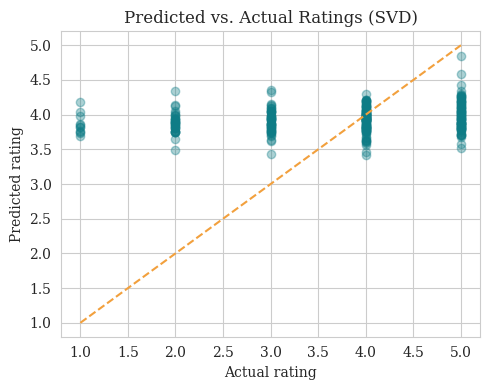

In [10]:
plt.figure(figsize=(5,4))
plt.scatter(y_true, y_pred, alpha=0.35, color='#0E7C86')
plt.plot([1,5],[1,5],'--', color='#F2A03D')
plt.xlabel('Actual rating'); plt.ylabel('Predicted rating')
plt.title('Predicted vs. Actual Ratings (SVD)')
plt.tight_layout(); plt.show()

In [12]:
print("Content-based, from a Pain Relief item:")
pain_relife_item = items[items['category']=='Pain Relief'].iloc[0]
display(content_based_recommend(pain_relife_item['item_id'], top_n=3))
print("\nCollaborative, for the same user shown above:")
display(collaborative_recommend(target_user, top_n=3))

Content-based, from a Pain Relief item:


,item_id,title,category,similarity
2,3,Premium Pain Relief Item 3,Pain Relief,0.788407
4,5,Extra-Strength Pain Relief Item 5,Pain Relief,0.782039
8,9,Everyday Pain Relief Item 9,Pain Relief,0.649216



Collaborative, for the same user shown above:


,item_id,title,category,predicted_rating
50,51,Extra-Strength Chronic Item 1,Chronic Care,3.098611
56,57,Everyday Chronic Item 7,Chronic Care,3.052685
58,59,Advanced Chronic Item 9,Chronic Care,3.042509
